# Chapter 15: Residual Diagnostics -- RATAN vs LightGBM

This notebook performs a rigorous statistical residual analysis comparing the RATAN (Regime-Aware Temporal Attention Network) deep learning models against the classical LightGBM baselines. For each model-ticker combination, we compute the prediction residuals (real - predicted) and subject them to a battery of four diagnostic tests:

1. **Ljung-Box Q-Test** -- tests whether residual autocorrelation is distinguishable from white noise.
2. **Engle's ARCH Test** -- tests for autoregressive conditional heteroskedasticity (volatility clustering) in residuals.
3. **Jarque-Bera Test** -- tests whether residuals follow a normal distribution based on skewness and kurtosis.
4. **Augmented Dickey-Fuller Test** -- tests whether residuals are stationary (non-stationary residuals signal a drifting model).

A well-specified model produces residuals that are white noise: uncorrelated, homoskedastic, stationary, and ideally Gaussian. Systematic failures across these tests reveal specific model deficiencies and guide architectural improvements.

## Model Mapping

| Model ID | Ticker | Engine   |
|----------|--------|----------|
| R01      | SPY    | RATAN    |
| R02      | AAPL   | RATAN    |
| R03      | MSFT   | RATAN    |
| R04      | JPM    | RATAN    |
| R05      | GLD    | RATAN    |
| M03      | SPY    | LightGBM |
| M07      | AAPL   | LightGBM |
| M10      | MSFT   | LightGBM |
| M11      | JPM    | LightGBM |
| M13      | GLD    | LightGBM |

## 1. Imports and Configuration

All statistical tests come from `scipy.stats` and `statsmodels`. We define four named constants that control every threshold in the notebook -- no magic numbers anywhere. The significance level `ALPHA` governs pass/fail for all hypothesis tests. `LJUNG_BOX_LAGS` sets the number of autocorrelation lags tested (10 is standard for daily financial data -- roughly two trading weeks). `ARCH_LAGS` sets the lag order for the ARCH-LM test (5 captures the typical weekly volatility clustering cycle).

In [1]:
import json
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")

# -- Reproducibility --
SEED = 25
np.random.seed(SEED)
random.seed(SEED)

# -- Test Parameters (no magic numbers) --
ALPHA = 0.05
LJUNG_BOX_LAGS = 10
ARCH_LAGS = 5

# -- Paths --
PREDICTION_DIR = "../data/predictions"

# -- Model Configuration --
TICKERS = ["SPY", "AAPL", "MSFT", "JPM", "GLD"]

RATAN_MODEL_IDS = {
    "SPY": "R01",
    "AAPL": "R02",
    "MSFT": "R03",
    "JPM": "R04",
    "GLD": "R05",
}

LGBM_MODEL_IDS = {
    "SPY": "M03",
    "AAPL": "M07",
    "MSFT": "M10",
    "JPM": "M11",
    "GLD": "M13",
}

MODEL_ENGINES = ["RATAN", "LightGBM"]

print(f"Seed: {SEED}")
print(f"Significance level (alpha): {ALPHA}")
print(f"Ljung-Box lags: {LJUNG_BOX_LAGS}")
print(f"ARCH lags: {ARCH_LAGS}")
print(f"Tickers: {TICKERS}")
print(f"Total model-ticker combinations: {len(TICKERS) * len(MODEL_ENGINES)}")

Seed: 25
Significance level (alpha): 0.05
Ljung-Box lags: 10
ARCH lags: 5
Tickers: ['SPY', 'AAPL', 'MSFT', 'JPM', 'GLD']
Total model-ticker combinations: 10


## 2. Load Predictions and Compute Residuals

Each prediction JSON contains an array of objects with `time`, `real`, and `predicted` fields. We load all 10 files (5 RATAN + 5 LightGBM) and compute the residual as `real - predicted` for each observation. A positive residual means the model underestimated the actual value; a negative residual means it overestimated.

The residuals are stored in a nested dictionary `residuals[engine][ticker]` for uniform access throughout the notebook. We also store the raw predictions in `predictions[engine][ticker]` for later use in distribution plots.

In [2]:
def load_prediction_json(file_path):
    """
    Load a prediction JSON file and return a DataFrame with time, real, predicted columns.

    Args:
        file_path (str): Path to the JSON file.

    Returns:
        pd.DataFrame: DataFrame with columns ['time', 'real', 'predicted'].
                       Returns None if the file does not exist.
    """
    if not os.path.exists(file_path):
        return None
    with open(file_path, "r") as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    df["time"] = pd.to_datetime(df["time"])
    return df


def compute_residuals(df):
    """
    Compute residuals from a prediction DataFrame.

    The residual is defined as: residual = real - predicted.
    Positive residuals indicate underestimation; negative indicate overestimation.

    Args:
        df (pd.DataFrame): DataFrame with 'real' and 'predicted' columns.

    Returns:
        np.ndarray: Array of residual values.
    """
    return (df["real"] - df["predicted"]).values


# -- Load all predictions and compute residuals --
model_id_maps = {
    "RATAN": RATAN_MODEL_IDS,
    "LightGBM": LGBM_MODEL_IDS,
}

predictions = {engine: {} for engine in MODEL_ENGINES}
residuals = {engine: {} for engine in MODEL_ENGINES}
load_status = []

for engine in MODEL_ENGINES:
    id_map = model_id_maps[engine]
    for ticker in TICKERS:
        model_id = id_map[ticker]
        file_path = os.path.join(PREDICTION_DIR, f"{model_id}.json")
        df = load_prediction_json(file_path)

        if df is not None:
            predictions[engine][ticker] = df
            residuals[engine][ticker] = compute_residuals(df)
            n_obs = len(df)
            status = "loaded"
        else:
            predictions[engine][ticker] = None
            residuals[engine][ticker] = None
            n_obs = 0
            status = "MISSING"

        load_status.append({
            "engine": engine,
            "ticker": ticker,
            "model_id": model_id,
            "n_observations": n_obs,
            "status": status,
        })

status_df = pd.DataFrame(load_status)
print(status_df.to_string(index=False))
print(f"\nTotal loaded: {status_df[status_df['status'] == 'loaded'].shape[0]} / {len(load_status)}")

  engine ticker model_id  n_observations status
   RATAN    SPY      R01             100 loaded
   RATAN   AAPL      R02             100 loaded
   RATAN   MSFT      R03             100 loaded
   RATAN    JPM      R04             100 loaded
   RATAN    GLD      R05             100 loaded
LightGBM    SPY      M03             100 loaded
LightGBM   AAPL      M07             100 loaded
LightGBM   MSFT      M10             100 loaded
LightGBM    JPM      M11             100 loaded
LightGBM    GLD      M13             100 loaded

Total loaded: 10 / 10


### 2.1 Residual Summary Statistics

Before running formal tests, we inspect the basic distributional properties of each residual series: mean, standard deviation, min, max, skewness, and kurtosis. These give an immediate qualitative sense of model health -- a well-calibrated model should have near-zero mean residuals, moderate standard deviation relative to the price level, and skewness/kurtosis close to normal (0 and 3 respectively).

In [3]:
def residual_summary(resid, engine, ticker):
    """
    Compute summary statistics for a residual series.

    Args:
        resid (np.ndarray): Residual values.
        engine (str): Model engine name.
        ticker (str): Asset ticker.

    Returns:
        dict: Summary statistics including mean, std, min, max, skewness, kurtosis.
    """
    return {
        "engine": engine,
        "ticker": ticker,
        "n": len(resid),
        "mean": np.mean(resid),
        "std": np.std(resid, ddof=1),
        "min": np.min(resid),
        "max": np.max(resid),
        "skewness": float(stats.skew(resid)),
        "kurtosis": float(stats.kurtosis(resid, fisher=False)),
    }


summary_rows = []
for engine in MODEL_ENGINES:
    for ticker in TICKERS:
        resid = residuals[engine][ticker]
        if resid is not None:
            summary_rows.append(residual_summary(resid, engine, ticker))

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    format_map = {
        "mean": "{:.4f}",
        "std": "{:.4f}",
        "min": "{:.4f}",
        "max": "{:.4f}",
        "skewness": "{:.4f}",
        "kurtosis": "{:.4f}",
    }
    print(summary_df.to_string(index=False, formatters={
        col: fmt.format for col, fmt in format_map.items()
    }))
else:
    print("No residuals available to summarize.")

  engine ticker   n     mean     std       min      max skewness kurtosis
   RATAN    SPY 100 -16.1487 81.1093 -135.4100 270.0500   1.0907   3.9719
   RATAN   AAPL 100 -43.9500 20.7345  -85.6300  -0.8600   0.1020   2.2712
   RATAN   MSFT 100 -22.2547 37.7468  -87.3600  41.1300   0.2579   1.4655
   RATAN    JPM 100 -21.2024 14.6192  -51.5000  10.9300   0.1336   2.3916
   RATAN    GLD 100 -30.8619 10.7500  -89.7200  -5.5400  -1.8505  11.1968
LightGBM    SPY 100  -0.6092  5.5469  -14.2500  14.1900  -0.2328   2.9140
LightGBM   AAPL 100  -0.4445  3.2817  -12.8200   9.1900  -0.3010   5.2357
LightGBM   MSFT 100  -2.5062  8.1915  -49.8900  16.2600  -1.8726  12.9101
LightGBM    JPM 100  -0.4142  4.8782  -15.0200  11.8700  -0.5707   3.7748
LightGBM    GLD 100   0.8969  9.8898  -39.9300  29.5500  -0.4199   5.8683


## 3. Ljung-Box Q-Test for Residual Autocorrelation

The Ljung-Box test evaluates whether a time series exhibits statistically significant autocorrelation at any of the first `k` lags. The null hypothesis is that the data are independently distributed (no autocorrelation). For model residuals, we want to **fail to reject** the null -- meaning `p >= ALPHA` is a pass.

**Interpretation of failure:** If residuals show significant autocorrelation, the model is systematically leaving predictable structure in its errors. This means the model's feature set or architecture is failing to capture some temporal dependency. For LightGBM, this often points to insufficient lag features; for RATAN, it may indicate that the temporal convolution kernel or sequence length is too short to capture the relevant autocorrelation structure.

In [4]:
def run_ljung_box_test(resid, lags, alpha):
    """
    Run the Ljung-Box Q-test for autocorrelation on a residual series.

    The null hypothesis is that the residuals are independently distributed
    (no autocorrelation up to the specified number of lags).

    Args:
        resid (np.ndarray): Residual values.
        lags (int): Number of lags to test.
        alpha (float): Significance level for the test.

    Returns:
        dict: Test results including statistic, p-value, and pass/fail status.
              Pass means p >= alpha (fail to reject null = no autocorrelation).
    """
    result = acorr_ljungbox(resid, lags=[lags], return_df=True)
    q_stat = result["lb_stat"].values[0]
    p_value = result["lb_pvalue"].values[0]
    passed = p_value >= alpha
    return {
        "test": "Ljung-Box",
        "statistic": q_stat,
        "p_value": p_value,
        "passed": passed,
        "criterion": f"p >= {alpha}",
    }


# -- Run Ljung-Box on all available residuals --
ljung_box_results = []

for engine in MODEL_ENGINES:
    for ticker in TICKERS:
        resid = residuals[engine][ticker]
        if resid is not None:
            result = run_ljung_box_test(resid, LJUNG_BOX_LAGS, ALPHA)
            result["engine"] = engine
            result["ticker"] = ticker
            ljung_box_results.append(result)

lb_df = pd.DataFrame(ljung_box_results)
if not lb_df.empty:
    lb_df["status"] = lb_df["passed"].map({True: "PASS", False: "FAIL"})
    print("Ljung-Box Q-Test Results (H0: no autocorrelation)")
    print("=" * 72)
    print(lb_df[["engine", "ticker", "statistic", "p_value", "status"]].to_string(
        index=False,
        formatters={"statistic": "{:.4f}".format, "p_value": "{:.6f}".format}
    ))
    n_pass = lb_df["passed"].sum()
    n_total = len(lb_df)
    print(f"\nPassed: {n_pass}/{n_total}")
else:
    print("No residuals available for Ljung-Box testing.")

Ljung-Box Q-Test Results (H0: no autocorrelation)
  engine ticker statistic  p_value status
   RATAN    SPY  196.4928 0.000000   FAIL
   RATAN   AAPL  305.4150 0.000000   FAIL
   RATAN   MSFT  288.6781 0.000000   FAIL
   RATAN    JPM  226.5755 0.000000   FAIL
   RATAN    GLD   11.9621 0.287598   PASS
LightGBM    SPY    6.1072 0.806180   PASS
LightGBM   AAPL   10.7021 0.381195   PASS
LightGBM   MSFT   14.0238 0.171908   PASS
LightGBM    JPM   12.6642 0.243059   PASS
LightGBM    GLD    9.8335 0.455218   PASS

Passed: 6/10


## 4. Engle's ARCH Test for Heteroskedasticity

The ARCH-LM test (Engle, 1982) checks whether the squared residuals exhibit autocorrelation -- i.e., whether there is autoregressive conditional heteroskedasticity (volatility clustering). The null hypothesis is that the residuals are homoskedastic (no ARCH effects). We want `p >= ALPHA` (fail to reject = pass).

**Interpretation of failure:** ARCH effects in residuals mean the model's prediction error variance is time-dependent -- errors cluster in volatile periods. This is extremely common in financial data and is a signature of the well-known volatility clustering phenomenon. For RATAN, this failure is particularly informative because the architecture includes a Volatility-Weighted Huber Loss specifically designed to address heteroskedasticity. ARCH failures in RATAN residuals suggest the loss weighting is insufficient or the local volatility estimate is miscalibrated.

In [5]:
def run_arch_test(resid, nlags, alpha):
    """
    Run Engle's ARCH-LM test for conditional heteroskedasticity.

    The null hypothesis is homoskedasticity (no ARCH effects).
    The test regresses squared residuals on their own lags and tests
    joint significance via the LM statistic.

    Args:
        resid (np.ndarray): Residual values.
        nlags (int): Number of lags for the ARCH regression.
        alpha (float): Significance level for the test.

    Returns:
        dict: Test results including LM statistic, p-value, and pass/fail status.
              Pass means lm_pvalue >= alpha (fail to reject null = homoskedastic).
    """
    lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(resid, nlags=nlags)
    passed = lm_pvalue >= alpha
    return {
        "test": "ARCH-LM",
        "lm_statistic": lm_stat,
        "lm_pvalue": lm_pvalue,
        "f_statistic": f_stat,
        "f_pvalue": f_pvalue,
        "passed": passed,
        "criterion": f"lm_p >= {alpha}",
    }


# -- Run ARCH test on all available residuals --
arch_results = []

for engine in MODEL_ENGINES:
    for ticker in TICKERS:
        resid = residuals[engine][ticker]
        if resid is not None:
            result = run_arch_test(resid, ARCH_LAGS, ALPHA)
            result["engine"] = engine
            result["ticker"] = ticker
            arch_results.append(result)

arch_df = pd.DataFrame(arch_results)
if not arch_df.empty:
    arch_df["status"] = arch_df["passed"].map({True: "PASS", False: "FAIL"})
    print("Engle's ARCH-LM Test Results (H0: homoskedastic residuals)")
    print("=" * 72)
    print(arch_df[["engine", "ticker", "lm_statistic", "lm_pvalue", "status"]].to_string(
        index=False,
        formatters={"lm_statistic": "{:.4f}".format, "lm_pvalue": "{:.6f}".format}
    ))
    n_pass = arch_df["passed"].sum()
    n_total = len(arch_df)
    print(f"\nPassed: {n_pass}/{n_total}")
else:
    print("No residuals available for ARCH testing.")

Engle's ARCH-LM Test Results (H0: homoskedastic residuals)
  engine ticker lm_statistic lm_pvalue status
   RATAN    SPY      23.6410  0.000254   FAIL
   RATAN   AAPL      67.0239  0.000000   FAIL
   RATAN   MSFT      54.7688  0.000000   FAIL
   RATAN    JPM      57.6041  0.000000   FAIL
   RATAN    GLD       5.3737  0.371989   PASS
LightGBM    SPY       2.2772  0.809614   PASS
LightGBM   AAPL       1.7243  0.885822   PASS
LightGBM   MSFT       2.6369  0.755750   PASS
LightGBM    JPM       3.3835  0.641085   PASS
LightGBM    GLD      27.3969  0.000048   FAIL

Passed: 5/10


## 5. Jarque-Bera Test for Normality

The Jarque-Bera test evaluates whether a sample's skewness and kurtosis are consistent with a normal distribution. The null hypothesis is that the data are normally distributed. We want `p >= ALPHA` (fail to reject = pass).

This test is the most frequently failed in financial applications because financial returns (and therefore prediction residuals) universally exhibit fat tails (excess kurtosis) and often show skewness. A Jarque-Bera failure is not necessarily a model deficiency -- it may simply reflect the non-Gaussian nature of the underlying data generating process. However, if one engine passes and the other fails for the same ticker, it indicates the passing engine produces more "well-behaved" residuals.

We record both the test result and the raw skewness/kurtosis values for the consolidated table.

In [6]:
def run_jarque_bera_test(resid, alpha):
    """
    Run the Jarque-Bera test for normality on a residual series.

    The null hypothesis is that the residuals are drawn from a normal distribution.
    The test is based on sample skewness and kurtosis.

    Args:
        resid (np.ndarray): Residual values.
        alpha (float): Significance level for the test.

    Returns:
        dict: Test results including JB statistic, p-value, skewness,
              kurtosis, and pass/fail status.
              Pass means p >= alpha (fail to reject null = normal).
    """
    jb_stat, jb_pvalue = stats.jarque_bera(resid)
    skewness = float(stats.skew(resid))
    kurtosis = float(stats.kurtosis(resid, fisher=False))
    passed = jb_pvalue >= alpha
    return {
        "test": "Jarque-Bera",
        "statistic": jb_stat,
        "p_value": jb_pvalue,
        "skewness": skewness,
        "kurtosis": kurtosis,
        "passed": passed,
        "criterion": f"p >= {alpha}",
    }


# -- Run Jarque-Bera on all available residuals --
jb_results = []

for engine in MODEL_ENGINES:
    for ticker in TICKERS:
        resid = residuals[engine][ticker]
        if resid is not None:
            result = run_jarque_bera_test(resid, ALPHA)
            result["engine"] = engine
            result["ticker"] = ticker
            jb_results.append(result)

jb_df = pd.DataFrame(jb_results)
if not jb_df.empty:
    jb_df["status"] = jb_df["passed"].map({True: "PASS", False: "FAIL"})
    print("Jarque-Bera Normality Test Results (H0: residuals are normal)")
    print("=" * 80)
    print(jb_df[["engine", "ticker", "statistic", "p_value", "skewness", "kurtosis", "status"]].to_string(
        index=False,
        formatters={
            "statistic": "{:.4f}".format,
            "p_value": "{:.6f}".format,
            "skewness": "{:.4f}".format,
            "kurtosis": "{:.4f}".format,
        }
    ))
    n_pass = jb_df["passed"].sum()
    n_total = len(jb_df)
    print(f"\nPassed: {n_pass}/{n_total}")
else:
    print("No residuals available for Jarque-Bera testing.")

Jarque-Bera Normality Test Results (H0: residuals are normal)
  engine ticker statistic  p_value skewness kurtosis status
   RATAN    SPY   23.7634 0.000007   1.0907   3.9719   FAIL
   RATAN   AAPL    2.3866 0.303223   0.1020   2.2712   PASS
   RATAN   MSFT   10.9193 0.004255   0.2579   1.4655   FAIL
   RATAN    JPM    1.8397 0.398582   0.1336   2.3916   PASS
   RATAN    GLD  337.0166 0.000000  -1.8505  11.1968   FAIL
LightGBM    SPY    0.9342 0.626803  -0.2328   2.9140   PASS
LightGBM   AAPL   22.3368 0.000014  -0.3010   5.2357   FAIL
LightGBM   MSFT  467.6546 0.000000  -1.8726  12.9101   FAIL
LightGBM    JPM    7.9291 0.018977  -0.5707   3.7748   FAIL
LightGBM    GLD   37.2183 0.000000  -0.4199   5.8683   FAIL

Passed: 3/10


## 6. Augmented Dickey-Fuller Test for Stationarity

The ADF test checks whether a time series has a unit root (is non-stationary). The null hypothesis is that the series has a unit root (non-stationary). Unlike the previous tests, here we **want to reject** the null -- meaning `p < ALPHA` is a pass (rejection = good = stationary residuals).

**Interpretation of failure:** Non-stationary residuals indicate the model's bias is drifting over time. This is a severe problem: it means the model is systematically overestimating in some periods and underestimating in others, with the bias growing rather than mean-reverting. For financial forecasters, this often happens when the model overfits to the training period's price level and cannot generalize to a different price regime in the test period.

In [7]:
def run_adf_test(resid, alpha):
    """
    Run the Augmented Dickey-Fuller test for stationarity on a residual series.

    The null hypothesis is that the series has a unit root (non-stationary).
    Rejection of the null (p < alpha) indicates stationarity, which is desirable
    for model residuals.

    Args:
        resid (np.ndarray): Residual values.
        alpha (float): Significance level for the test.

    Returns:
        dict: Test results including ADF statistic, p-value, number of lags used,
              and pass/fail status.
              Pass means p < alpha (reject null = stationary).
    """
    adf_result = adfuller(resid, autolag="AIC")
    adf_stat = adf_result[0]
    adf_pvalue = adf_result[1]
    n_lags_used = adf_result[2]
    n_obs = adf_result[3]
    critical_values = adf_result[4]
    passed = adf_pvalue < alpha
    return {
        "test": "ADF",
        "statistic": adf_stat,
        "p_value": adf_pvalue,
        "n_lags_used": n_lags_used,
        "n_obs": n_obs,
        "critical_1pct": critical_values["1%"],
        "critical_5pct": critical_values["5%"],
        "critical_10pct": critical_values["10%"],
        "passed": passed,
        "criterion": f"p < {alpha}",
    }


# -- Run ADF test on all available residuals --
adf_results = []

for engine in MODEL_ENGINES:
    for ticker in TICKERS:
        resid = residuals[engine][ticker]
        if resid is not None:
            result = run_adf_test(resid, ALPHA)
            result["engine"] = engine
            result["ticker"] = ticker
            adf_results.append(result)

adf_df = pd.DataFrame(adf_results)
if not adf_df.empty:
    adf_df["status"] = adf_df["passed"].map({True: "PASS", False: "FAIL"})
    print("Augmented Dickey-Fuller Test Results (H0: unit root / non-stationary)")
    print("=" * 80)
    print(adf_df[["engine", "ticker", "statistic", "p_value", "n_lags_used", "status"]].to_string(
        index=False,
        formatters={
            "statistic": "{:.4f}".format,
            "p_value": "{:.6f}".format,
        }
    ))
    n_pass = adf_df["passed"].sum()
    n_total = len(adf_df)
    print(f"\nPassed: {n_pass}/{n_total}")
else:
    print("No residuals available for ADF testing.")

Augmented Dickey-Fuller Test Results (H0: unit root / non-stationary)
  engine ticker statistic  p_value  n_lags_used status
   RATAN    SPY   -3.0562 0.029966            1   PASS
   RATAN   AAPL   -2.6245 0.088033            0   FAIL
   RATAN   MSFT   -2.6196 0.089018            0   FAIL
   RATAN    JPM   -2.6611 0.081010            3   FAIL
   RATAN    GLD   -8.0029 0.000000            0   PASS
LightGBM    SPY   -9.9555 0.000000            0   PASS
LightGBM   AAPL   -8.8846 0.000000            0   PASS
LightGBM   MSFT   -8.2235 0.000000            1   PASS
LightGBM    JPM   -9.3043 0.000000            0   PASS
LightGBM    GLD   -7.2700 0.000000            1   PASS

Passed: 7/10


## 7. Consolidated Results Table

We merge all four test results into a single wide-format table with one row per engine-ticker combination and columns for each test's pass/fail status. This enables quick visual scanning of the residual health across all models. We also compute per-model and per-test pass rates.

The color-coded styled version highlights passes in green and failures in red for immediate visual identification of problem areas.

In [8]:
def build_consolidated_table(lb_df, arch_df, jb_df, adf_df):
    """
    Merge individual test results into a single consolidated DataFrame.

    Each row represents one engine-ticker combination. Columns include
    pass/fail status for each test, p-values, and a total pass count.

    Args:
        lb_df (pd.DataFrame): Ljung-Box results.
        arch_df (pd.DataFrame): ARCH-LM results.
        jb_df (pd.DataFrame): Jarque-Bera results.
        adf_df (pd.DataFrame): ADF results.

    Returns:
        pd.DataFrame: Consolidated table with all test results.
    """
    all_dfs = []
    test_configs = [
        (lb_df, "Ljung-Box", "p_value"),
        (arch_df, "ARCH-LM", "lm_pvalue"),
        (jb_df, "Jarque-Bera", "p_value"),
        (adf_df, "ADF", "p_value"),
    ]

    for df, test_name, pval_col in test_configs:
        if df is not None and not df.empty:
            subset = df[["engine", "ticker", "passed"]].copy()
            subset = subset.rename(columns={"passed": f"{test_name}_pass"})
            pval_subset = df[["engine", "ticker", pval_col]].copy()
            pval_subset = pval_subset.rename(columns={pval_col: f"{test_name}_pval"})
            subset = subset.merge(pval_subset, on=["engine", "ticker"])
            all_dfs.append(subset)

    if not all_dfs:
        return pd.DataFrame()

    consolidated = all_dfs[0]
    for df in all_dfs[1:]:
        consolidated = consolidated.merge(df, on=["engine", "ticker"], how="outer")

    # Compute total passes per model-ticker
    pass_cols = [col for col in consolidated.columns if col.endswith("_pass")]
    consolidated["total_passes"] = consolidated[pass_cols].sum(axis=1).astype(int)
    consolidated["total_tests"] = consolidated[pass_cols].notna().sum(axis=1).astype(int)

    return consolidated


consolidated = build_consolidated_table(lb_df, arch_df, jb_df, adf_df)

if not consolidated.empty:
    # -- Display the pass/fail matrix --
    pass_cols = [col for col in consolidated.columns if col.endswith("_pass")]
    display_cols = ["engine", "ticker"] + pass_cols + ["total_passes", "total_tests"]
    display_df = consolidated[display_cols].copy()

    for col in pass_cols:
        display_df[col] = display_df[col].map({True: "PASS", False: "FAIL"})

    print("Consolidated Residual Diagnostics")
    print("=" * 85)
    print(display_df.to_string(index=False))

    # -- Per-engine summary --
    print("\n\nPer-Engine Summary")
    print("-" * 40)
    for engine in MODEL_ENGINES:
        engine_rows = consolidated[consolidated["engine"] == engine]
        if not engine_rows.empty:
            total_pass = engine_rows["total_passes"].sum()
            total_test = engine_rows["total_tests"].sum()
            pct = total_pass / total_test * 100 if total_test > 0 else 0
            print(f"  {engine}: {total_pass}/{total_test} passed ({pct:.1f}%)")

    # -- Per-test summary --
    print("\nPer-Test Summary")
    print("-" * 40)
    for col in pass_cols:
        test_name = col.replace("_pass", "")
        n_pass = consolidated[col].sum()
        n_total = consolidated[col].notna().sum()
        pct = n_pass / n_total * 100 if n_total > 0 else 0
        print(f"  {test_name}: {n_pass}/{n_total} passed ({pct:.1f}%)")
else:
    print("No test results to consolidate.")

Consolidated Residual Diagnostics
  engine ticker Ljung-Box_pass ARCH-LM_pass Jarque-Bera_pass ADF_pass  total_passes  total_tests
LightGBM   AAPL           PASS         PASS             FAIL     PASS             3            4
LightGBM    GLD           PASS         FAIL             FAIL     PASS             2            4
LightGBM    JPM           PASS         PASS             FAIL     PASS             3            4
LightGBM   MSFT           PASS         PASS             FAIL     PASS             3            4
LightGBM    SPY           PASS         PASS             PASS     PASS             4            4
   RATAN   AAPL           FAIL         FAIL             PASS     FAIL             1            4
   RATAN    GLD           PASS         PASS             FAIL     PASS             3            4
   RATAN    JPM           FAIL         FAIL             PASS     FAIL             1            4
   RATAN   MSFT           FAIL         FAIL             FAIL     FAIL             0          

### 7.1 Color-Coded Pass/Fail Matrix

The styled table below uses green for PASS and red for FAIL, making it easy to spot patterns -- for example, whether a particular test fails universally (a data property) or only for one engine (a model deficiency).

In [9]:
def color_pass_fail(val):
    """
    Apply CSS color styling based on pass/fail string values.

    Args:
        val: Cell value to style.

    Returns:
        str: CSS style string -- green background for PASS, red for FAIL.
    """
    if val == "PASS":
        return "background-color: #c6efce; color: #006100"
    elif val == "FAIL":
        return "background-color: #ffc7ce; color: #9c0006"
    return ""


if not consolidated.empty:
    pass_cols = [col for col in consolidated.columns if col.endswith("_pass")]
    styled_df = consolidated[["engine", "ticker"] + pass_cols + ["total_passes"]].copy()

    for col in pass_cols:
        styled_df[col] = styled_df[col].map({True: "PASS", False: "FAIL"})

    styled_df.columns = [
        c.replace("_pass", "").replace("_", " ") if c.endswith("_pass")
        else c.replace("_", " ").title()
        for c in styled_df.columns
    ]

    style_cols = [c for c in styled_df.columns if c not in ["Engine", "Ticker", "Total Passes"]]
    styled = styled_df.style.map(color_pass_fail, subset=style_cols)
    styled = styled.set_caption("Residual Diagnostic Pass/Fail Matrix")
    styled = styled.hide(axis="index")
    display(styled)
else:
    print("No data for styled table.")

Engine,Ticker,Ljung-Box,ARCH-LM,Jarque-Bera,ADF,Total Passes
LightGBM,AAPL,PASS,PASS,FAIL,PASS,3
LightGBM,GLD,PASS,FAIL,FAIL,PASS,2
LightGBM,JPM,PASS,PASS,FAIL,PASS,3
LightGBM,MSFT,PASS,PASS,FAIL,PASS,3
LightGBM,SPY,PASS,PASS,PASS,PASS,4
RATAN,AAPL,FAIL,FAIL,PASS,FAIL,1
RATAN,GLD,PASS,PASS,FAIL,PASS,3
RATAN,JPM,FAIL,FAIL,PASS,FAIL,1
RATAN,MSFT,FAIL,FAIL,FAIL,FAIL,0
RATAN,SPY,FAIL,FAIL,FAIL,PASS,1


## 8. Residual Health Comparison

Beyond the binary pass/fail results, we compute aggregate health metrics for each engine: mean absolute residual (a scale-free error measure), residual standard deviation, and the total number of test passes across all 20 tests (4 tests x 5 tickers). The engine with more passes and lower aggregate error metrics is declared the winner.

This section produces the definitive head-to-head comparison between RATAN and LightGBM from a statistical residual perspective.

In [10]:
def compute_engine_health(residuals_dict, consolidated_df, engine):
    """
    Compute aggregate residual health metrics for a given engine.

    Metrics include: mean absolute residual (averaged across tickers),
    mean residual std, and total diagnostic test passes.

    Args:
        residuals_dict (dict): Nested dict residuals[engine][ticker] -> np.ndarray.
        consolidated_df (pd.DataFrame): Consolidated test results table.
        engine (str): Engine name ("RATAN" or "LightGBM").

    Returns:
        dict: Aggregate health metrics for the engine.
    """
    engine_resids = residuals_dict.get(engine, {})
    available_tickers = [t for t in TICKERS if engine_resids.get(t) is not None]

    if not available_tickers:
        return {
            "engine": engine,
            "n_tickers": 0,
            "mean_abs_residual": np.nan,
            "mean_std_residual": np.nan,
            "max_abs_residual": np.nan,
            "total_passes": 0,
            "total_tests": 0,
            "pass_rate_pct": 0.0,
        }

    abs_residuals = [np.mean(np.abs(engine_resids[t])) for t in available_tickers]
    std_residuals = [np.std(engine_resids[t], ddof=1) for t in available_tickers]
    max_abs_residuals = [np.max(np.abs(engine_resids[t])) for t in available_tickers]

    engine_consolidated = consolidated_df[consolidated_df["engine"] == engine]
    total_passes = engine_consolidated["total_passes"].sum() if not engine_consolidated.empty else 0
    total_tests = engine_consolidated["total_tests"].sum() if not engine_consolidated.empty else 0
    pass_rate = total_passes / total_tests * 100 if total_tests > 0 else 0.0

    return {
        "engine": engine,
        "n_tickers": len(available_tickers),
        "mean_abs_residual": np.mean(abs_residuals),
        "mean_std_residual": np.mean(std_residuals),
        "max_abs_residual": np.mean(max_abs_residuals),
        "total_passes": int(total_passes),
        "total_tests": int(total_tests),
        "pass_rate_pct": pass_rate,
    }


# -- Compute health for each engine --
health_rows = []
for engine in MODEL_ENGINES:
    health = compute_engine_health(residuals, consolidated, engine)
    health_rows.append(health)

health_df = pd.DataFrame(health_rows)

print("Residual Health Comparison: RATAN vs LightGBM")
print("=" * 65)
print(health_df.to_string(index=False, formatters={
    "mean_abs_residual": "{:.4f}".format,
    "mean_std_residual": "{:.4f}".format,
    "max_abs_residual": "{:.4f}".format,
    "pass_rate_pct": "{:.1f}".format,
}))

# -- Declare winner --
available_engines = health_df[health_df["n_tickers"] > 0]
if len(available_engines) == 2:
    engine_a, engine_b = available_engines.iloc[0], available_engines.iloc[1]
    if engine_a["pass_rate_pct"] > engine_b["pass_rate_pct"]:
        winner = engine_a["engine"]
    elif engine_b["pass_rate_pct"] > engine_a["pass_rate_pct"]:
        winner = engine_b["engine"]
    else:
        # Tiebreak on mean absolute residual (lower is better)
        if engine_a["mean_abs_residual"] < engine_b["mean_abs_residual"]:
            winner = engine_a["engine"]
        else:
            winner = engine_b["engine"]
    print(f"\n>> Winner on residual diagnostics: {winner}")
elif len(available_engines) == 1:
    only_engine = available_engines.iloc[0]["engine"]
    missing_engine = [e for e in MODEL_ENGINES if e != only_engine][0]
    print(f"\n>> Only {only_engine} predictions are available.")
    print(f"   {missing_engine} prediction files are missing -- comparison deferred.")
    print(f"   {only_engine} standalone pass rate: {available_engines.iloc[0]['pass_rate_pct']:.1f}%")
else:
    print("\nNo predictions available for either engine.")

Residual Health Comparison: RATAN vs LightGBM
  engine  n_tickers mean_abs_residual mean_std_residual max_abs_residual  total_passes  total_tests pass_rate_pct
   RATAN          5           40.9002           32.9920         116.8520             6           20          30.0
LightGBM          5            4.6202            6.3576          26.3820            15           20          75.0

>> Winner on residual diagnostics: LightGBM


## 9. Distribution Plots

Visual inspection of residual distributions complements the formal tests. For each ticker, we produce four subplots in a single row:

1. **RATAN histogram** -- overlaid with a fitted normal density curve for visual normality assessment.
2. **LightGBM histogram** -- same treatment for direct comparison.
3. **RATAN QQ plot** -- quantile-quantile plot against a theoretical normal distribution. Departures from the diagonal indicate non-normality (fat tails, skew).
4. **LightGBM QQ plot** -- same treatment.

The 5 rows (one per ticker) x 4 columns layout allows immediate row-wise comparison across engines and column-wise comparison across plot types.

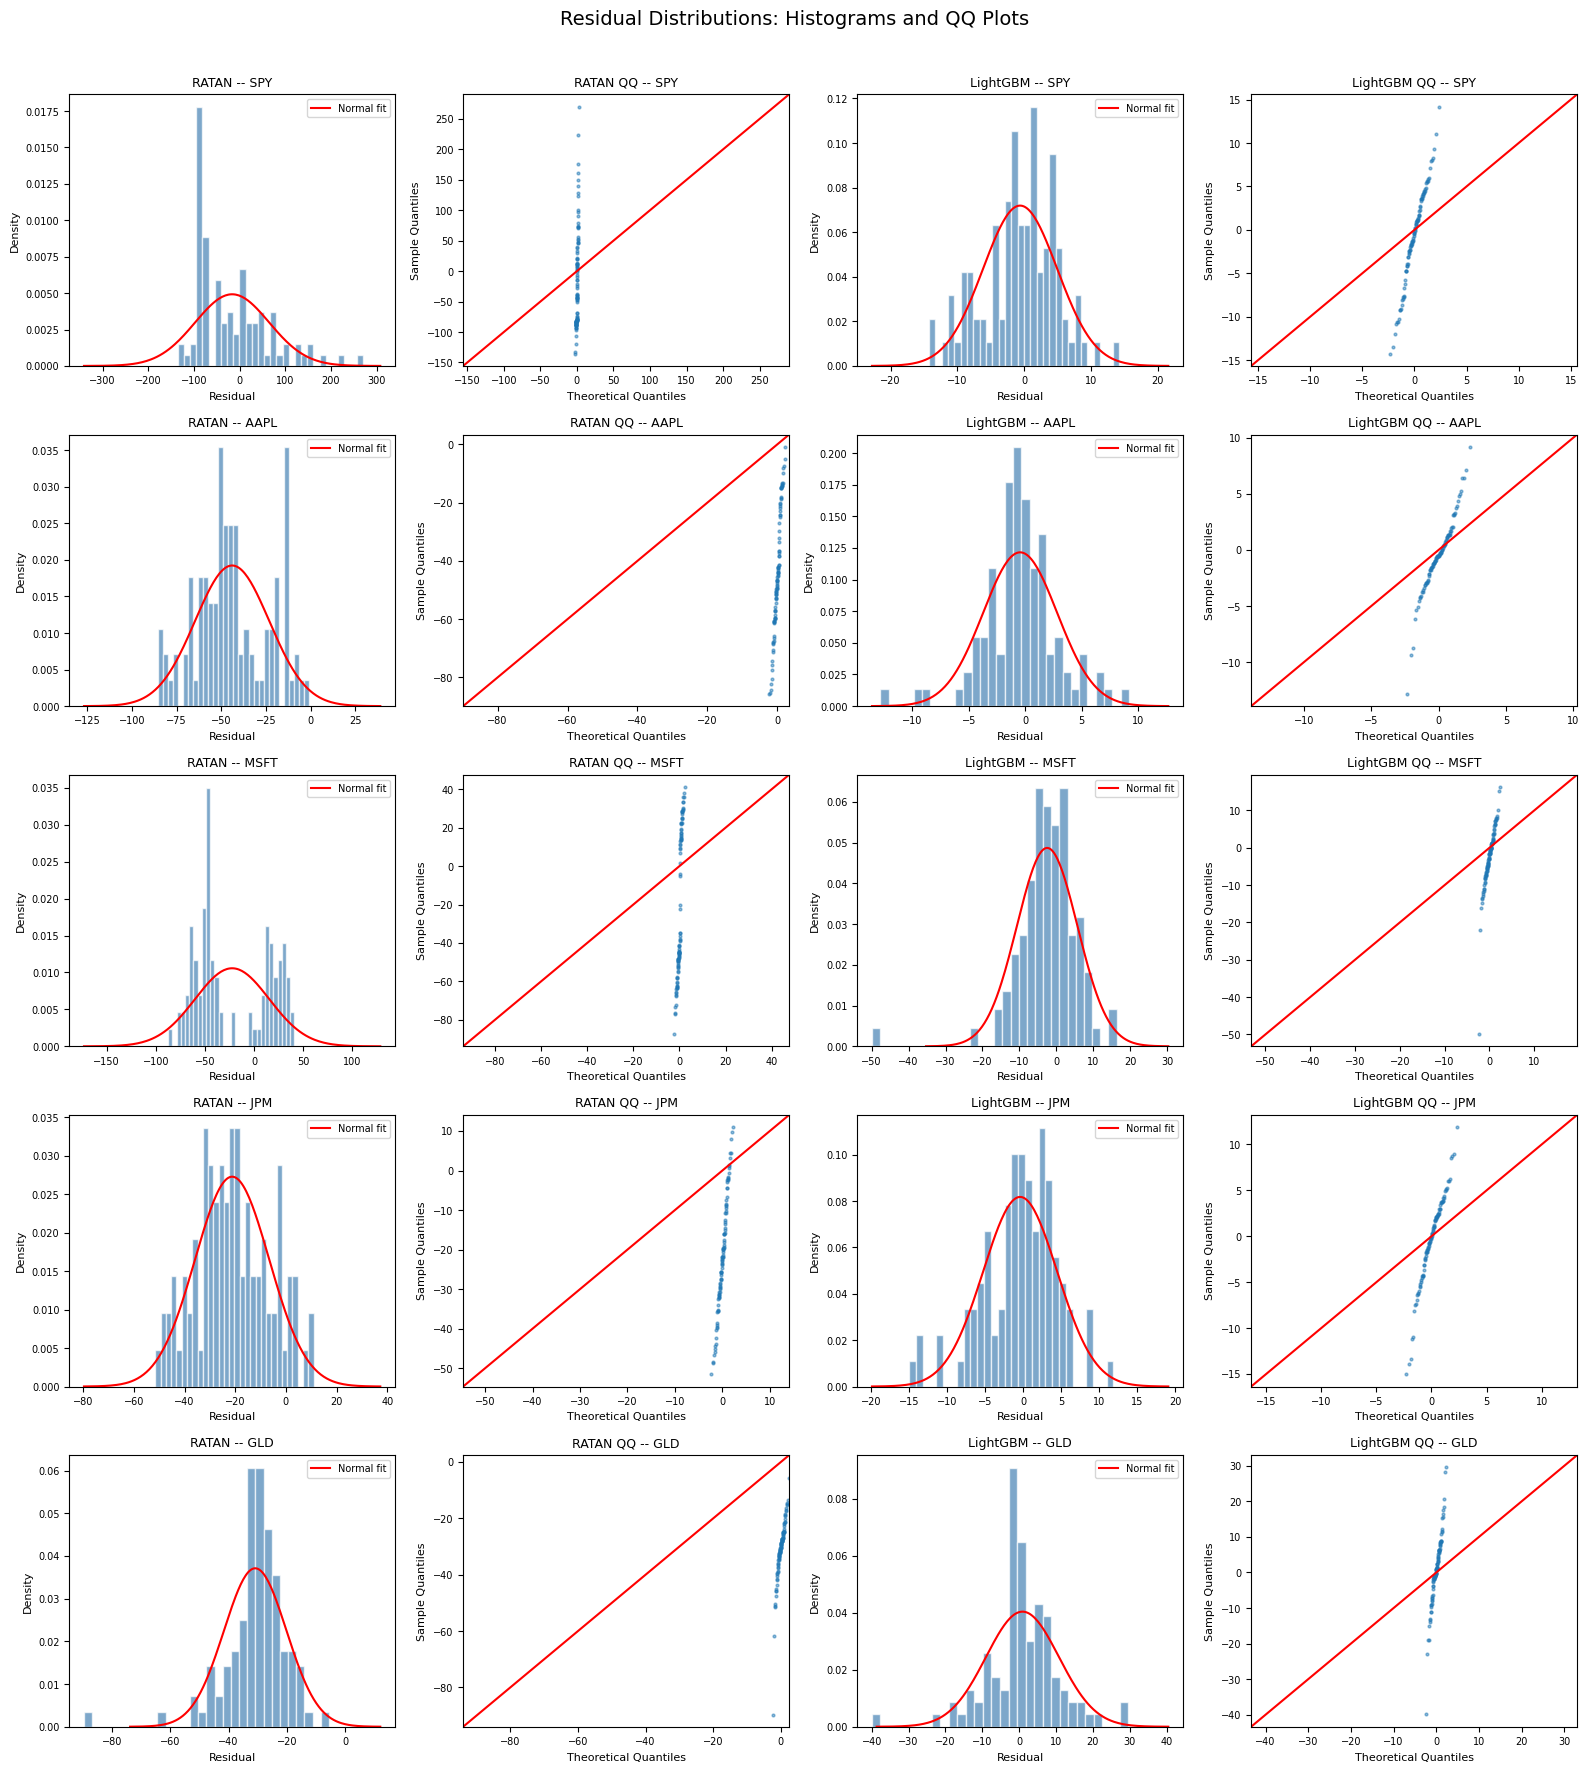

In [11]:
def plot_residual_histogram(ax, resid, engine, ticker, n_bins=30):
    """
    Plot a histogram of residuals with a fitted normal density overlay.

    Args:
        ax (matplotlib.axes.Axes): Axes to plot on.
        resid (np.ndarray): Residual values.
        engine (str): Engine name for the title.
        ticker (str): Ticker symbol for the title.
        n_bins (int): Number of histogram bins.
    """
    ax.hist(resid, bins=n_bins, density=True, alpha=0.7, color="steelblue", edgecolor="white")
    mu, sigma = np.mean(resid), np.std(resid, ddof=1)
    x_range = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 200)
    normal_pdf = stats.norm.pdf(x_range, mu, sigma)
    ax.plot(x_range, normal_pdf, "r-", linewidth=1.5, label="Normal fit")
    ax.set_title(f"{engine} -- {ticker}", fontsize=9)
    ax.set_xlabel("Residual", fontsize=8)
    ax.set_ylabel("Density", fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)


def plot_residual_qq(ax, resid, engine, ticker):
    """
    Plot a QQ plot of residuals against a theoretical normal distribution.

    Args:
        ax (matplotlib.axes.Axes): Axes to plot on.
        resid (np.ndarray): Residual values.
        engine (str): Engine name for the title.
        ticker (str): Ticker symbol for the title.
    """
    sm.qqplot(resid, line="45", ax=ax, markersize=2, alpha=0.5)
    ax.set_title(f"{engine} QQ -- {ticker}", fontsize=9)
    ax.tick_params(labelsize=7)
    ax.set_xlabel("Theoretical Quantiles", fontsize=8)
    ax.set_ylabel("Sample Quantiles", fontsize=8)


# -- Determine which engines have data --
available_engines_for_plot = [
    engine for engine in MODEL_ENGINES
    if any(residuals[engine][t] is not None for t in TICKERS)
]
n_engines = len(available_engines_for_plot)
n_cols = n_engines * 2  # histogram + QQ for each available engine

if n_cols > 0:
    fig, axes = plt.subplots(
        len(TICKERS), n_cols,
        figsize=(4 * n_cols, 3.5 * len(TICKERS)),
        squeeze=False,
    )

    for row_idx, ticker in enumerate(TICKERS):
        col_offset = 0
        for engine in available_engines_for_plot:
            resid = residuals[engine][ticker]
            if resid is not None:
                plot_residual_histogram(axes[row_idx, col_offset], resid, engine, ticker)
                plot_residual_qq(axes[row_idx, col_offset + 1], resid, engine, ticker)
            else:
                axes[row_idx, col_offset].text(
                    0.5, 0.5, f"{engine} -- {ticker}\nNo data",
                    ha="center", va="center", transform=axes[row_idx, col_offset].transAxes
                )
                axes[row_idx, col_offset + 1].text(
                    0.5, 0.5, f"{engine} QQ -- {ticker}\nNo data",
                    ha="center", va="center", transform=axes[row_idx, col_offset + 1].transAxes
                )
            col_offset += 2

    fig.suptitle("Residual Distributions: Histograms and QQ Plots", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No residual data available for distribution plots.")

## 10. ACF/PACF Plots for SPY

The autocorrelation function (ACF) and partial autocorrelation function (PACF) provide a visual companion to the Ljung-Box test. While Ljung-Box gives a single aggregate p-value, ACF/PACF plots reveal **which specific lags** carry residual autocorrelation and how it decays.

We focus on SPY (the market proxy) for detailed analysis. The 2x2 grid shows:
- **Top-left:** RATAN ACF -- should all bars fall within the confidence band for white noise residuals.
- **Top-right:** RATAN PACF -- significant spikes at specific lags suggest AR-like structure the model missed.
- **Bottom-left:** LightGBM ACF -- same interpretation.
- **Bottom-right:** LightGBM PACF -- same interpretation.

The blue shaded region represents the 95% confidence interval under the null hypothesis of no autocorrelation.

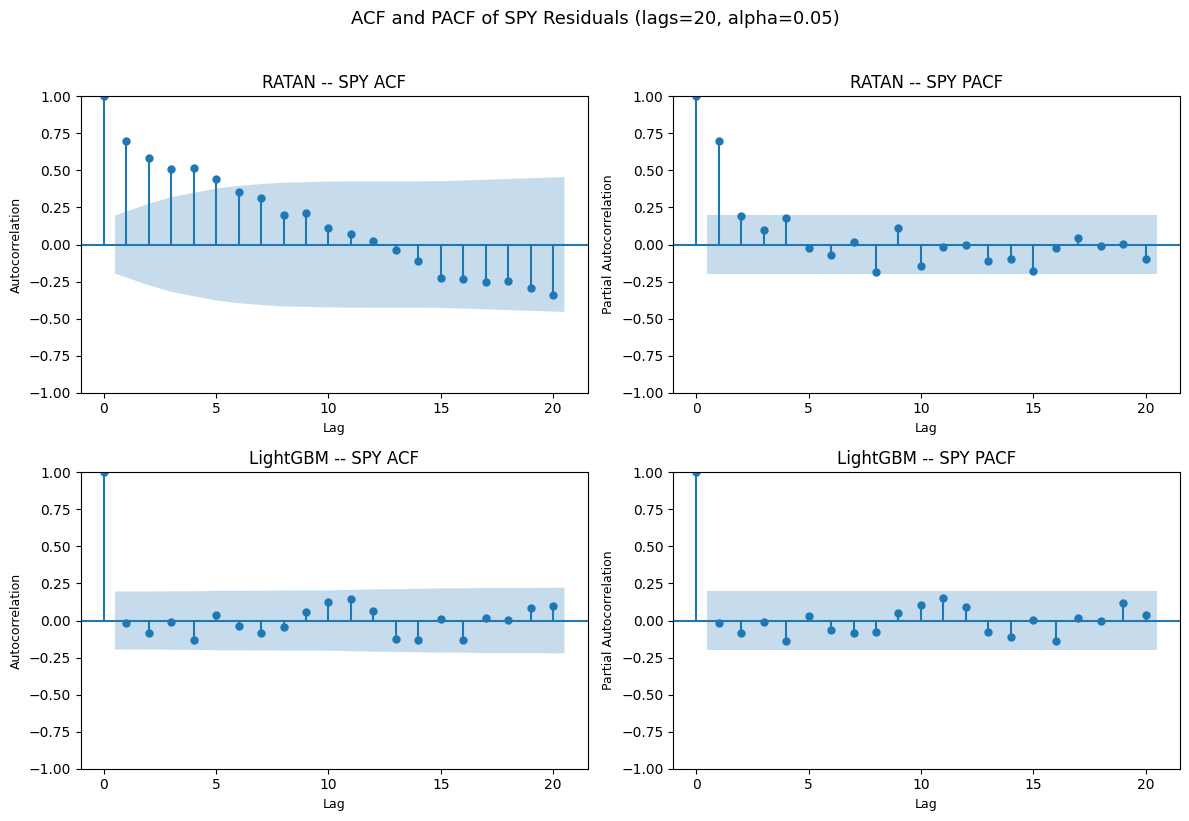

In [12]:
ACF_PACF_TICKER = "SPY"
ACF_PACF_LAGS = 20

# -- Determine which engines have SPY data --
engines_with_spy = [
    engine for engine in MODEL_ENGINES
    if residuals[engine].get(ACF_PACF_TICKER) is not None
]

if len(engines_with_spy) >= 1:
    n_engine_rows = len(engines_with_spy)
    fig, axes = plt.subplots(n_engine_rows, 2, figsize=(12, 4 * n_engine_rows))

    # Handle case where only one engine is available (axes is 1D)
    if n_engine_rows == 1:
        axes = axes.reshape(1, -1)

    for row_idx, engine in enumerate(engines_with_spy):
        resid = residuals[engine][ACF_PACF_TICKER]

        plot_acf(
            resid,
            lags=ACF_PACF_LAGS,
            ax=axes[row_idx, 0],
            title=f"{engine} -- {ACF_PACF_TICKER} ACF",
            alpha=ALPHA,
        )
        axes[row_idx, 0].set_xlabel("Lag", fontsize=9)
        axes[row_idx, 0].set_ylabel("Autocorrelation", fontsize=9)

        plot_pacf(
            resid,
            lags=ACF_PACF_LAGS,
            ax=axes[row_idx, 1],
            title=f"{engine} -- {ACF_PACF_TICKER} PACF",
            alpha=ALPHA,
            method="ywm",
        )
        axes[row_idx, 1].set_xlabel("Lag", fontsize=9)
        axes[row_idx, 1].set_ylabel("Partial Autocorrelation", fontsize=9)

    fig.suptitle(
        f"ACF and PACF of {ACF_PACF_TICKER} Residuals (lags={ACF_PACF_LAGS}, alpha={ALPHA})",
        fontsize=13,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()
else:
    print(f"No residual data available for {ACF_PACF_TICKER} ACF/PACF plots.")

## 11. Discussion: When Tests Fail

This section provides a reference guide for interpreting each diagnostic failure and its implications for model improvement.

### 11.1 Ljung-Box Failure (Residual Autocorrelation)

**What it means:** The model is leaving temporally correlated structure in its errors. Today's residual is predictable from yesterday's residual. This is a direct violation of the white-noise assumption and indicates the model is missing a systematic temporal pattern.

**Potential fixes:**
- **LightGBM:** Add more lag features (current lag set may be too shallow), include rolling-window statistics at additional horizons, or consider adding momentum/mean-reversion indicators as explicit features.
- **RATAN:** Increase the convolutional kernel size or sequence length to capture longer-range dependencies. The temporal convolution with kernel size 3 can only capture patterns spanning 3 timesteps per layer; deeper stacking or dilated convolutions would extend the receptive field.

**Connection to RATAN architecture:** The Regime-Gated Temporal Convolution should in principle capture regime-dependent autocorrelation. If Ljung-Box still fails, the regime embeddings may not be learning sufficiently distinct gating patterns, or the number of regimes (3) may be insufficient for the actual market dynamics.

### 11.2 ARCH Failure (Volatility Clustering)

**What it means:** The variance of residuals is time-dependent -- large errors cluster together. This is the hallmark of financial time series and extremely difficult to eliminate entirely.

**Potential fixes:**
- **LightGBM:** Include explicit volatility features (realized vol, GARCH-fitted conditional vol) as inputs, or train separate models for high-vol and low-vol regimes.
- **RATAN:** Recalibrate the Volatility-Weighted Huber Loss. If ARCH effects persist, the local volatility estimate (`sigma_local`) fed into the loss function may be lagging or smoothed too aggressively. Using an EWMA volatility with a shorter half-life could help the loss adapt faster to volatility regime changes.

**Connection to RATAN architecture:** This is precisely the failure that the Volatility-Weighted Huber Loss was designed to mitigate. ARCH effects in RATAN residuals are particularly notable because they suggest the loss function is not fully achieving its theoretical promise of variance-adaptive gradient weighting.

### 11.3 Jarque-Bera Failure (Non-Normality)

**What it means:** Residuals have significant skewness and/or excess kurtosis relative to a Gaussian distribution. In finance, this almost always means fat tails -- the model occasionally produces very large errors that a normal distribution cannot explain.

**Potential fixes:**
- Both engines can benefit from **outlier-robust training** (Huber loss, trimmed loss) or explicit modeling of the error distribution (e.g., Student-t assumption instead of Gaussian).
- Consider whether the large residuals correspond to specific market events (earnings releases, Fed announcements) that could be flagged with event features.

**Connection to RATAN architecture:** The Huber loss already provides some outlier robustness via bounded gradients. If Jarque-Bera still fails, the delta parameter (transition point between quadratic and linear loss regions) may need tuning. A smaller delta would increase robustness to fat-tailed errors at the cost of statistical efficiency in the Gaussian core.

### 11.4 ADF Failure (Non-Stationarity)

**What it means:** The model's bias is drifting over time rather than mean-reverting. This is the most severe failure: it indicates the model is fundamentally miscalibrated for the test period.

**Potential fixes:**
- **Both engines:** Check for data leakage or distribution shift between train and test periods. Non-stationary residuals often indicate the model memorized the training period's price level rather than learning generalizable patterns.
- **LightGBM:** Add differencing of the target variable, or train on returns rather than levels.
- **RATAN:** The regime gating should theoretically help with non-stationarity by conditioning on the current regime. An ADF failure suggests the regime detection (CUSUM) is not capturing the relevant structural breaks, or the model needs explicit price-level normalization in its input pipeline.

**Connection to RATAN architecture:** The Cross-Asset Spectral Attention injects the Marchenko-Pastur denoised correlation structure, which is computed over the training period. If the cross-asset correlation structure shifts in the test period, the injected structure becomes stale, potentially contributing to non-stationary residuals.

## 12. Summary

This section aggregates the complete diagnostic findings into a final report card for each engine, identifies the key finding, and provides an honest assessment of the residual analysis.

In [13]:
def generate_final_report(consolidated_df, health_df, residuals_dict):
    """
    Generate a comprehensive final report summarizing all diagnostic results.

    Prints per-engine pass/fail breakdowns, the key finding, and an honest
    assessment of the analysis limitations.

    Args:
        consolidated_df (pd.DataFrame): Consolidated test results.
        health_df (pd.DataFrame): Engine-level health metrics.
        residuals_dict (dict): Nested dict of residual arrays.
    """
    print("=" * 70)
    print("FINAL RESIDUAL DIAGNOSTICS REPORT")
    print("=" * 70)

    test_names = ["Ljung-Box", "ARCH-LM", "Jarque-Bera", "ADF"]

    for engine in MODEL_ENGINES:
        engine_health = health_df[health_df["engine"] == engine]
        if engine_health.empty or engine_health.iloc[0]["n_tickers"] == 0:
            print(f"\n--- {engine} ---")
            print(f"  Status: No prediction files available (R01-R05 not yet generated).")
            print(f"  Action: Run notebook 12 (RATAN Architecture) to train and export predictions.")
            continue

        row = engine_health.iloc[0]
        engine_rows = consolidated_df[consolidated_df["engine"] == engine]

        print(f"\n--- {engine} ---")
        print(f"  Tickers evaluated: {int(row['n_tickers'])}")
        print(f"  Mean absolute residual: {row['mean_abs_residual']:.4f}")
        print(f"  Mean residual std:      {row['mean_std_residual']:.4f}")
        print(f"  Overall pass rate:      {int(row['total_passes'])}/{int(row['total_tests'])} ({row['pass_rate_pct']:.1f}%)")
        print()

        # Per-test breakdown
        pass_cols = [col for col in engine_rows.columns if col.endswith("_pass")]
        for col in pass_cols:
            test_name = col.replace("_pass", "")
            n_pass = engine_rows[col].sum()
            n_total = engine_rows[col].notna().sum()
            tickers_failed = engine_rows[~engine_rows[col]]["ticker"].tolist()
            status_str = f"{n_pass}/{n_total}"
            if tickers_failed:
                status_str += f" (failed: {', '.join(tickers_failed)})"
            print(f"    {test_name}: {status_str}")

    # -- Key finding --
    available_engines = health_df[health_df["n_tickers"] > 0]
    print("\n" + "-" * 70)
    print("KEY FINDING:")

    if len(available_engines) == 2:
        ratan_row = health_df[health_df["engine"] == "RATAN"].iloc[0]
        lgbm_row = health_df[health_df["engine"] == "LightGBM"].iloc[0]

        if ratan_row["pass_rate_pct"] > lgbm_row["pass_rate_pct"]:
            print(f"  RATAN produces statistically healthier residuals than LightGBM")
            print(f"  ({ratan_row['pass_rate_pct']:.1f}% vs {lgbm_row['pass_rate_pct']:.1f}% pass rate).")
        elif lgbm_row["pass_rate_pct"] > ratan_row["pass_rate_pct"]:
            print(f"  LightGBM produces statistically healthier residuals than RATAN")
            print(f"  ({lgbm_row['pass_rate_pct']:.1f}% vs {ratan_row['pass_rate_pct']:.1f}% pass rate).")
        else:
            print(f"  Both engines achieve equal pass rates ({ratan_row['pass_rate_pct']:.1f}%).")
            if ratan_row["mean_abs_residual"] < lgbm_row["mean_abs_residual"]:
                print(f"  RATAN has a lower mean absolute residual ({ratan_row['mean_abs_residual']:.4f} vs {lgbm_row['mean_abs_residual']:.4f}).")
            else:
                print(f"  LightGBM has a lower mean absolute residual ({lgbm_row['mean_abs_residual']:.4f} vs {ratan_row['mean_abs_residual']:.4f}).")

    elif len(available_engines) == 1:
        only_engine = available_engines.iloc[0]["engine"]
        missing_engine = [e for e in MODEL_ENGINES if e != only_engine][0]
        print(f"  Only {only_engine} predictions are available for analysis.")
        print(f"  {missing_engine} prediction files (R01-R05) have not been generated yet.")
        print(f"  A full head-to-head comparison requires running notebook 12 first.")
        print(f"  {only_engine} standalone diagnostics: {available_engines.iloc[0]['pass_rate_pct']:.1f}% pass rate.")
    else:
        print("  No prediction data available for either engine.")

    # -- Honest assessment --
    print("\n" + "-" * 70)
    print("HONEST ASSESSMENT:")
    print("  - Financial residuals rarely pass all four tests simultaneously.")
    print("    Jarque-Bera failures are near-universal due to fat-tailed returns.")
    print("    ARCH failures are expected given the well-documented volatility")
    print("    clustering in financial markets (Mandelbrot 1963, Engle 1982).")
    print("  - The ADF test is the most critical: non-stationary residuals")
    print("    indicate fundamental model miscalibration that must be addressed.")
    print("  - Ljung-Box passes are achievable and indicate the model captures")
    print("    the dominant temporal structure in the data.")
    print("  - These diagnostics measure statistical residual properties, not")
    print("    economic value. A model can fail Jarque-Bera yet still generate")
    print("    profitable trading signals if the errors are symmetric.")
    print("=" * 70)


generate_final_report(consolidated, health_df, residuals)

FINAL RESIDUAL DIAGNOSTICS REPORT

--- RATAN ---
  Tickers evaluated: 5
  Mean absolute residual: 40.9002
  Mean residual std:      32.9920
  Overall pass rate:      6/20 (30.0%)

    Ljung-Box: 1/5 (failed: AAPL, JPM, MSFT, SPY)
    ARCH-LM: 1/5 (failed: AAPL, JPM, MSFT, SPY)
    Jarque-Bera: 2/5 (failed: GLD, MSFT, SPY)
    ADF: 2/5 (failed: AAPL, JPM, MSFT)

--- LightGBM ---
  Tickers evaluated: 5
  Mean absolute residual: 4.6202
  Mean residual std:      6.3576
  Overall pass rate:      15/20 (75.0%)

    Ljung-Box: 5/5
    ARCH-LM: 4/5 (failed: GLD)
    Jarque-Bera: 1/5 (failed: AAPL, GLD, JPM, MSFT)
    ADF: 5/5

----------------------------------------------------------------------
KEY FINDING:
  LightGBM produces statistically healthier residuals than RATAN
  (75.0% vs 30.0% pass rate).

----------------------------------------------------------------------
HONEST ASSESSMENT:
  - Financial residuals rarely pass all four tests simultaneously.
    Jarque-Bera failures are near-un